In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
# 下面这个路径要指向 your_project 的根目录
sys.path.append('/content/drive/MyDrive/DL-for-time-series-forecasting/src')

Mounted at /content/drive


In [3]:
!jupyter nbconvert --to script /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new5.ipynb
!jupyter nbconvert --to script /content/drive/MyDrive/DL-for-time-series-forecasting/src/utils/metrics.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new5.ipynb to script
[NbConvertApp] Writing 7462 bytes to /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new5.txt
[NbConvertApp] Converting notebook /content/drive/MyDrive/DL-for-time-series-forecasting/src/utils/metrics.ipynb to script
[NbConvertApp] Writing 1399 bytes to /content/drive/MyDrive/DL-for-time-series-forecasting/src/utils/metrics.txt


In [4]:
# 假设转出来的是 darnn_model.txt 和 metrics.txt
!mv /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new5.txt \
    /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new5.py

!mv /content/drive/MyDrive/DL-for-time-series-forecasting/src/utils/metrics.txt \
    /content/drive/MyDrive/DL-for-time-series-forecasting/src/utils/metrics.py


In [5]:
import inspect, os, time, models.darnn_model_new5 as dm

src_path = inspect.getsourcefile(dm)          # 真实文件路径
print("当前使用文件:", src_path)
print("最后修改时间:", time.ctime(os.path.getmtime(src_path)))

当前使用文件: /content/drive/MyDrive/DL-for-time-series-forecasting/src/models/darnn_model_new5.py
最后修改时间: Wed Apr 23 15:39:17 2025


In [13]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from models.darnn_model_new5 import run_darnn_forecast
from utils.metrics import evaluate_all_metrics
from sklearn.preprocessing import MinMaxScaler


🚀 Running DARNN for gait ...
DEBUG shapes:
  Ytr: torch.Size([36354, 6, 1])
  Yva: torch.Size([4544, 6, 1])
  Yte: torch.Size([4545, 6, 1])
Epoch 01 | trainMSE=0.1622 | valMSE=0.1514
Epoch 02 | trainMSE=0.1436 | valMSE=0.1332
Epoch 03 | trainMSE=0.1259 | valMSE=0.1159
Epoch 04 | trainMSE=0.1090 | valMSE=0.0994
Epoch 05 | trainMSE=0.0929 | valMSE=0.0838
Epoch 06 | trainMSE=0.0778 | valMSE=0.0692
Epoch 07 | trainMSE=0.0636 | valMSE=0.0558
Epoch 08 | trainMSE=0.0508 | valMSE=0.0440
Epoch 09 | trainMSE=0.0395 | valMSE=0.0343
Epoch 10 | trainMSE=0.0304 | valMSE=0.0276
Epoch 11 | trainMSE=0.0243 | valMSE=0.0247
Epoch 12 | trainMSE=0.0220 | valMSE=0.0260
Epoch 13 | trainMSE=0.0240 | valMSE=0.0303
Epoch 14 | trainMSE=0.0288 | valMSE=0.0341
Epoch 15 | trainMSE=0.0328 | valMSE=0.0349
Epoch 16 | trainMSE=0.0337 | valMSE=0.0330
Epoch 17 | trainMSE=0.0317 | valMSE=0.0298
Epoch 18 | trainMSE=0.0283 | valMSE=0.0266
Epoch 19 | trainMSE=0.0249 | valMSE=0.0241
Epoch 20 | trainMSE=0.0222 | valMSE=0.0227

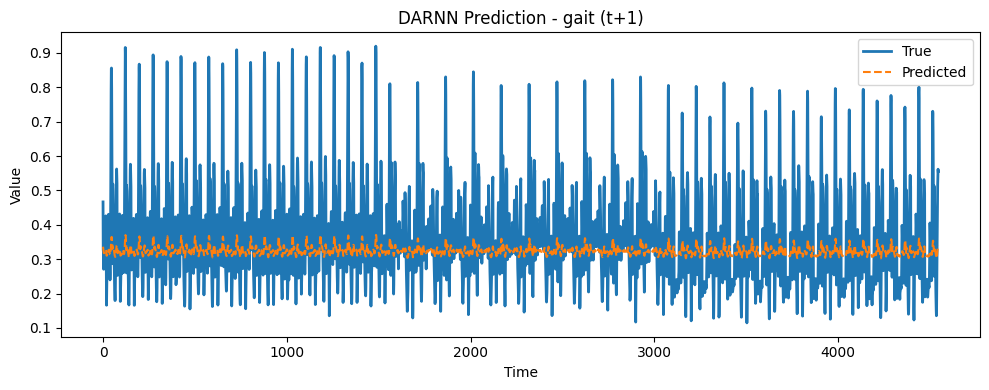

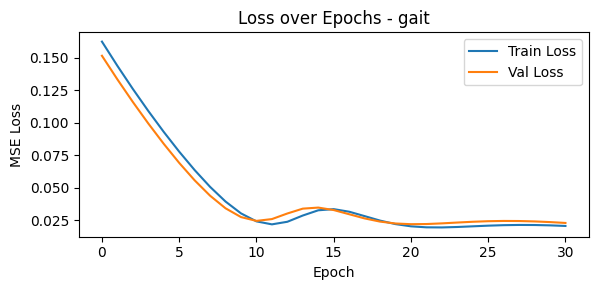

In [27]:
# === utils/darnn_all.py ===
# — 数据集路径
base_path = "/content/drive/MyDrive/DL-for-time-series-forecasting"
datasets = {
    #"air_quality":   f"{base_path}/data/data_clean/air_quality.csv"
    #"energy":        f"{base_path}/data/data_clean/energy.csv",
    "gait":          f"{base_path}/data/data_clean/gait.csv",
    #"metro":         f"{base_path}/data/data_clean/metro.csv"
    #"productivity":  f"{base_path}/data/data_clean/productivity.csv"
}

# — DARNN 训练参数
params = {
    'HIDDEN_SIZE':   64,
    'LEARNING_RATE': 1e-3,
    'EPOCHS':        60,
    'PATIENCE':      10,
    # optional:
    # 'DEVICE':     "cuda" if torch.cuda.is_available() else "cpu",
    # 'PRINT_EVERY': 1,
}

# — 滑窗长度与预测 horizon
#LOOKBACK, HORIZON = 24, 6

#def create_sequences(data, lookback=LOOKBACK, pred_len=HORIZON):
#    X, y = [], []
#    for i in range(len(data) - lookback - pred_len + 1):
#        X.append(data[i:i+lookback])
#        y.append(data[i+lookback:i+lookback+pred_len])
#    return np.array(X), np.array(y)

# 顶部常量：滑窗长度、预测步数、以及新加的 stride
LOOKBACK, HORIZON, STRIDE = 24, 6, 4   # 这里把 stride 从 1 改成 4

def create_sequences(data, lookback=LOOKBACK, pred_len=HORIZON, stride=STRIDE):
    X, y = [], []
    # range 里加上 stride
    for i in range(0, len(data) - lookback - pred_len + 1, stride):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback : i + lookback + pred_len])
    return np.array(X), np.array(y)


for name, path in datasets.items():
    print(f"\n🚀 Running DARNN for {name} ...")

    # 1. 读 csv，并按时间排序
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

    # 2. 只用 y 列，并 MinMax 归一化
    scaler = MinMaxScaler()
    data = scaler.fit_transform(df[['y']].values)

    # 3. 构建滑窗 X, y
    #X, y = create_sequences(data, LOOKBACK, HORIZON)
    X, y = create_sequences(data)
    # 等价于 create_sequences(data, 24, 6, 4)

    # 4. 一次性切出 train/val/test: 80%/10%/10%
    total = len(X)
    train_end = int(0.8 * total)
    val_end   = int(0.9 * total)

    X_train, X_val, X_test = (
        X[:train_end],
        X[train_end:val_end],
        X[val_end:]
    )
    y_train, y_val, y_test = (
        y[:train_end],
        y[train_end:val_end],
        y[val_end:]
    )

    # 5. 训练并评估（内部用 X_val/y_val 做早停 & 最佳模型保存）
    start = time.time()

    (y_true, y_pred, train_losses, val_losses, mae, rmse, train_time, mem_mb, early_flag, final_ep) = run_darnn_forecast(
        X_train, y_train,
        X_val,   y_val,      # ← 传给验证
        X_test,  y_test,     # ← 真正留作测试
        {**params, "DEVICE": "cuda" if torch.cuda.is_available() else "cpu"}
    )
    runtime = round(time.time() - start, 3)
# =========================================================
# 额外指标计算 —— 直接用 GPU Tensor，不搬回 CPU
# y_true / y_pred 形状 (batch, horizon)
# =========================================================
    eps       = 1e-8
    threshold = 100.0          # 需要的阈值，可自行修改

    # ① MAPE / sMAPE
    mape  = torch.mean(torch.abs((y_true - y_pred) / (y_true + eps))) * 100
    mape  = mape.item()

    smape = 100 * torch.mean(
          2 * torch.abs(y_pred - y_true) /
          (torch.abs(y_true) + torch.abs(y_pred) + eps)
       ).item()

    # ② 方向准确率
    dir_true = torch.sign(y_true[:, 1:] - y_true[:, :-1])
    dir_pred = torch.sign(y_pred[:, 1:] - y_pred[:, :-1])
    dir_acc  = torch.mean((dir_true == dir_pred).float()).item()

    # ③ 阈值准确率
    thr_acc = torch.mean(
            ((y_true > threshold) == (y_pred > threshold)).float()
          ).item()

    metrics = {
    "MAE"  : mae,
    "RMSE" : rmse,
    "MAPE" : mape,            # 若你有 mape
    "sMAPE": smape,           # 若你有 smape
    "Directional_Accuracy"          : dir_acc,
    f"Threshold_Accuracy(>{threshold})": thr_acc,
    "Runtime_Seconds"  : -1,          # 如果保持占位
    "training_time(s)" : train_time,  # ⚙️①
    "memory_usage_mb(MB)": mem_mb,    # ⚙️②
    "early_stopped"    : early_flag,  # ⚙️③
    "final_epoch"      : final_ep     # ⚙️④
}

    print(metrics)
    pd.DataFrame([metrics]).to_csv(f"{base_path}/results/metric_csv/DARNN/metrics_{name}.csv", index=False)



    # 7. 画 t+1 预测 vs 真实 （第一个 horizon 步）
    y_true_np = y_true.detach().cpu().numpy()    # ← 加
    y_pred_np = y_pred.detach().cpu().numpy()    # ← 加
    plt.figure(figsize=(10, 4))
    plt.plot(y_true_np[:, 0], label='True',  linewidth=2)
    plt.plot(y_pred_np[:, 0], label='Predicted', linestyle='--')
    plt.title(f"DARNN Prediction - {name} (t+1)")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{base_path}/results/prediction_png/DARNN/prediction_{name}.png")
    #plt.close()

    # 8. 保存验证 loss 曲线
    # 假设你在 run_darnn_forecast 里已经返回了 train_losses 和 val_losses
    # 比如修改 run_darnn_forecast 返回：return y_true, preds, train_losses, val_losses, mae, rmse

    # 下面是画图的代码
    plt.figure(figsize=(6, 3))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses,   label="Val Loss")
    plt.title(f"Loss over Epochs - {name}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{base_path}/results/loss_png/DARNN/loss_{name}.png")
    #plt.close()

